* ISIC Challenge datasets

In [1]:
!git clone https://github.com/andreiionut1411/trustworthy-federated-skin-lesion.git

Cloning into 'trustworthy-federated-skin-lesion'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 103 (delta 39), reused 75 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 3.89 MiB | 6.70 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [2]:
!pip install -U "flwr[simulation]"
!pip install -U ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 134.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.3/323.3 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.1/250.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 727.1/727.1 kB 57.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
     

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 MB 16.7 MB/s eta 0:00:00
  Attempting uninstall: ray
    Found existing installation: ray 2.51.1
    Uninstalling ray-2.51.1:
      Successfully uninstalled ray-2.51.1


In [3]:
!pip install -r /content/trustworthy-federated-skin-lesion/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 131.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.0/732.0 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# This is for Andrei's drive
!unzip /content/drive/MyDrive/AITDM/AITDM/covid_jpg.zip -d /content

Datele de ieșire de afișat au fost trunchiate la ultimele 5000 linii.
  inflating: /content/val/377e27f0-1fd5-4cc3-93df-6c491ef2d755.jpg  
  inflating: /content/val/A120120-12-31-1900-NA-CHEST_AP_VIEWONLY-00315-3.000000-AP-99574-1-1.jpg  
  inflating: /content/val/sub-S10170_ses-E20536_run-1_bp-chest_vp-ap_dx-corrected.jpg  
  inflating: /content/val/A683471-01-02-1901-NA-CHEST_AP_VIEWONLY-40155-2.000000-AP-77751-1-1.jpg  
  inflating: /content/val/A240623-12-31-1900-NA-CHEST_AP_VIEWONLY-84669-1.000000-AP-58394-1-1.jpg  
  inflating: /content/val/sub-S09875_ses-E53220_run-1_bp-chest_vp-ap_dx-corrected.jpg  
  inflating: /content/val/sub-S09995_ses-E26500_run-1_bp-chest_vp-pa_dx-corrected.jpg  
  inflating: /content/val/4a8d9d7e-0723-4267-af11-5efdc877aead.jpg  
  inflating: /content/val/sub-S03148_ses-E62595_run-1_bp-chest_vp-pa_dx-corrected.jpg  
  inflating: /content/val/61afee15-8240-404d-b1a8-aa6e5581d038.jpg  
  inflating: /content/val/A496404-12-28-1900-NA-CHEST_AP_VIEWONLY-64251

1. Import the libs

In [5]:
import pandas as pd
import numpy as np
import threading
from collections import defaultdict
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
import flwr as fl
from PIL import Image
from sklearn.model_selection import train_test_split
import os
from torchvision import transforms
from tqdm import tqdm
from flwr.common import Context, parameters_to_ndarrays, NDArrays, ArrayRecord
from sklearn.metrics import precision_recall_fscore_support
from pathlib import Path
import pickle
import random
from torchvision import models, transforms
from collections import OrderedDict
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


2. Statistics of the datasets

All the images were preprocessed using the `data_processing/preprocess.py` to images of 256 x 256 pixels for uniformity to reduce the domain shift.

Covidx CXR-4 - The dataset we will use for federated learning

In [6]:
import pandas as pd

# Load your txt files
train_df = pd.read_csv("train.txt", sep=" ", header=None, index_col=False, names=["patient_id", "filename", "label", "source"])
val_df   = pd.read_csv("val.txt",   sep=" ", header=None, index_col=False, names=["patient_id", "filename", "label", "source"])
test_df  = pd.read_csv("test.txt",  sep=" ", header=None, index_col=False, names=["patient_id", "filename", "label", "source"])

# Combine for global stats (optional)
df = pd.concat([train_df,], axis=0).reset_index(drop=True)

# Compute stats
num_images = len(df)
num_patients = df['patient_id'].nunique()
num_classes = df['label'].nunique()
class_counts = df['label'].value_counts()
source_counts = df['source'].value_counts()

print(f"Total images: {num_images}")
print(f"Total patients: {num_patients}")
print(f"Classes: {num_classes}")
print("\nClass distribution:\n", class_counts)
print("\nSource distribution:\n", source_counts)

print("\n--- Train/Val/Test split sizes ---")
print(f"Train: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")


Total images: 67863
Total patients: 35457
Classes: 2

Class distribution:
 label
positive    57199
negative    10664
Name: count, dtype: int64

Source distribution:
 source
bimcv         43142
stonybrook    12696
rsna           9719
sirm            878
ricord          834
cohen           471
actmed          101
fig1             22
Name: count, dtype: int64

--- Train/Val/Test split sizes ---
Train: 67863
Val:   8473
Test:  8482


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


3. Split the data for Federated Learning

We need to simulate the real life where data is non-IID. We only have the source labels. Unfortunately bimcv has 99% positives which is too imbalanced, so we need another way aside from the sources to split the data. We will do this with a Dirichlet distribution.

We are 3 people, so we need to split the data into 3 parts. Furthermore, we want to have 3 clients for federated learning, so in total we will have 5 splits.

In [7]:
def split_patients_federated(txt_path, num_clients=3, alpha=0.3, seed=42):
    np.random.seed(seed)

    # Load TXT
    df = pd.read_csv(
        txt_path, sep=" ", header=None, index_col=False,
        names=["patient_id", "filename", "label", "source"]
    )

    # Treat filename as patient_id to avoid leakage
    df["patient_id"] = df["filename"]

    client_assignments = {i: [] for i in range(num_clients)}

    # Stratified by label
    for label_value in df['label'].unique():
        subset = df[df['label'] == label_value]
        patients = subset["patient_id"].unique()
        np.random.shuffle(patients)
        num_patients = len(patients)

        # Dirichlet proportions
        proportions = np.random.dirichlet([alpha] * num_clients)

        # Convert to counts
        client_sizes = (proportions * num_patients).astype(int)
        while client_sizes.sum() < num_patients:
            client_sizes[np.argmax(proportions)] += 1

        # Assign patients to clients
        idx = 0
        for cid, size in enumerate(client_sizes):
            assigned = patients[idx:idx + size]
            client_assignments[cid].extend(assigned)
            idx += size

    # Build client datasets
    df["client_id"] = -1
    for cid in range(num_clients):
        df.loc[df["patient_id"].isin(client_assignments[cid]), "client_id"] = cid

    # Print summary
    print("\n=========== STRATIFIED DIRICHLET FEDERATED SUMMARY ===========")
    for cid in range(num_clients):
        cdf = df[df["client_id"] == cid]
        print(f"\n--- Client {cid} ---")
        print(f"Images: {len(cdf)}")
        print(f"Patients: {cdf['patient_id'].nunique()}")
        print("\nLabel distribution:")
        print(cdf['label'].value_counts())
        print("\nSource distribution:")
        print(cdf['source'].value_counts())
        print("----------------------------------------------------")

    df_to_save = df[["patient_id", "filename", "label", "source", "client_id"]]
    df_to_save.to_csv(txt_path, sep=" ", header=False, index=False)
    print(f"\n✅ TXT file with client IDs saved to: {txt_path}")

    return df

In [8]:
train_path = "train.txt"
client_splits = split_patients_federated(train_path, alpha=1.5, seed=54, num_clients=5)


=========== STRATIFIED DIRICHLET FEDERATED SUMMARY ===========

--- Client 0 ---
Images: 13581
Patients: 13581

Label distribution:
label
positive    12680
negative      901
Name: count, dtype: int64

Source distribution:
source
bimcv         9466
stonybrook    2791
rsna           819
ricord         207
sirm           205
cohen           80
actmed           9
fig1             4
Name: count, dtype: int64
----------------------------------------------------

--- Client 1 ---
Images: 17376
Patients: 17375

Label distribution:
label
positive    13324
negative     4052
Name: count, dtype: int64

Source distribution:
source
bimcv         10079
rsna           3685
stonybrook     3029
sirm            211
ricord          193
cohen           136
actmed           38
fig1              5
Name: count, dtype: int64
----------------------------------------------------

--- Client 2 ---
Images: 7429
Patients: 7428

Label distribution:
label
positive    6001
negative    1428
Name: count, dtype: int64



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


We will use splits 0, 2 and 3 for federated learning. We will have split 1 for fine-tuning and split 4 for DP.

In [9]:
path = "val.txt"
client_splits = split_patients_federated(path, alpha=1.5, seed=54, num_clients=5)


=========== STRATIFIED DIRICHLET FEDERATED SUMMARY ===========

--- Client 0 ---
Images: 1394
Patients: 1394

Label distribution:
label
negative    764
positive    630
Name: count, dtype: int64

Source distribution:
source
rsna          687
bimcv         527
stonybrook    129
cohen          20
ricord         14
sirm           10
actmed          6
fig1            1
Name: count, dtype: int64
----------------------------------------------------

--- Client 1 ---
Images: 658
Patients: 658

Label distribution:
label
positive    506
negative    152
Name: count, dtype: int64

Source distribution:
source
bimcv         387
rsna          142
stonybrook    109
sirm           10
ricord          6
cohen           3
actmed          1
Name: count, dtype: int64
----------------------------------------------------

--- Client 2 ---
Images: 1533
Patients: 1533

Label distribution:
label
negative    1169
positive     364
Name: count, dtype: int64

Source distribution:
source
rsna          1072
bimcv    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
path = "test.txt"
client_splits = split_patients_federated(path, alpha=1.5, seed=54, num_clients=4)


=========== STRATIFIED DIRICHLET FEDERATED SUMMARY ===========

--- Client 0 ---
Images: 1900
Patients: 1900

Label distribution:
label
positive    1212
negative     688
Name: count, dtype: int64

Source distribution:
source
bimcv     1805
ricord      53
rsna        42
Name: count, dtype: int64
----------------------------------------------------

--- Client 1 ---
Images: 2021
Patients: 2021

Label distribution:
label
negative    1048
positive     973
Name: count, dtype: int64

Source distribution:
source
bimcv     1915
rsna        55
ricord      51
Name: count, dtype: int64
----------------------------------------------------

--- Client 2 ---
Images: 2949
Patients: 2949

Label distribution:
label
negative    2248
positive     701
Name: count, dtype: int64

Source distribution:
source
bimcv     2825
rsna        94
ricord      30
Name: count, dtype: int64
----------------------------------------------------

--- Client 3 ---
Images: 1612
Patients: 1612

Label distribution:
label
posit

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


We use id 0 for testing for the federated set-up.

4. Create the Federated Learning set-up

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything()

Using device: cuda


In [12]:
class CovidDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        if os.path.exists(img_path):
            image = Image.open(img_path).convert('RGB')
        else:
            image = Image.new('RGB', (256, 256))

        label = torch.tensor([1.0 if self.df.iloc[idx]['label']=="positive" else 0.0], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [13]:
def get_model():
    """Load ResNet18 with a single output neuron for Binary Classification."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

def set_parameters(model, parameters):
    """Apply weights from Server to Client Model."""
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

In [14]:
def train_local(model, train_loader, epochs, lr, device):
    model.train()
    model.to(device)
    pos_weight = torch.tensor([20.0]).to(device)
    pw = torch.tensor([pos_weight], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    total_examples = 0
    running_loss = 0.0

    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_examples = 0
        pbar = tqdm(train_loader, desc=f"Train epoch {epoch+1}/{epochs}", leave=False, ncols=100)
        for X, y in pbar:
            X = X.to(device)
            y = y.to(device).float()

            optimizer.zero_grad()
            outputs = model(X)
            outputs = outputs.view(-1)
            labels = y.view(-1)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_size = X.size(0)
            epoch_loss += loss.item() * batch_size
            epoch_examples += batch_size

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_epoch_loss = epoch_loss / epoch_examples if epoch_examples > 0 else 0.0
        print(f"Epoch {epoch+1}/{epochs} - Avg loss: {avg_epoch_loss:.6f}")

        running_loss += epoch_loss
        total_examples += epoch_examples

    avg_loss = running_loss / total_examples if total_examples > 0 else 0.0
    return avg_loss


def evaluate(model, dataloader, device):
    model.eval()
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()

    threshold = 0.5
    total_loss = 0.0
    total_examples = 0

    # counters for binary confusion matrix
    TP = 0
    TN = 0
    FP = 0
    FN = 0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device).float()

            outputs = model(X)
            outputs = outputs.view(-1)

            batch_size = X.size(0)
            loss = criterion(outputs, y.view(-1))
            total_loss += loss.item() * batch_size
            total_examples += batch_size

            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).long()
            labels = y.view(-1).long()

            TP += int(((preds == 1) & (labels == 1)).sum().item())
            TN += int(((preds == 0) & (labels == 0)).sum().item())
            FP += int(((preds == 1) & (labels == 0)).sum().item())
            FN += int(((preds == 0) & (labels == 1)).sum().item())

    avg_loss = total_loss / total_examples if total_examples > 0 else 0.0
    eps = 1e-8
    precision = TP / (TP + FP + eps)
    recall = TP / (TP + FN + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    accuracy = (TP + TN) / (TP + TN + FP + FN + eps)

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": TP,
        "tn": TN,
        "fp": FP,
        "fn": FN,
    }
    print(
        f"Eval - Loss: {avg_loss:.6f} | "
        f"Acc: {accuracy:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f} | F1: {f1:.4f} | "
        f"TP: {TP} FP: {FP} FN: {FN} TN: {TN}"
    )

    return avg_loss, metrics


In [15]:
def load_partition(txt_path, client_id, img_dir, split="train", batch_size=None):
    """
    Load dataset for a client and print debug info.
    """
    # --- load CSV ---
    df = pd.read_csv(
        txt_path, sep=" ", header=None, index_col=False,
        names=["patient_id", "filename", "label", "source", "client_id"]
    )
    client_df = df[df["client_id"] == client_id].copy()

    # --- create dataset ---
    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
    ])
    dataset = CovidDataset(client_df, img_dir=os.path.join(img_dir, split), transform=transform)

    # inspect first 3 samples
    for i in range(min(3, len(dataset))):
        img_path = os.path.join(dataset.img_dir, client_df.iloc[i]['filename'])
        raw_img = Image.open(img_path).convert('RGB')
        raw_tensor = transforms.ToTensor()(raw_img)
        transformed_tensor, label = dataset[i]

    return dataset

In [16]:
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, model, client_txt_path, client_id, img_dir, device, local_epochs=1, lr=1e-4, batch_size=32):
        self.model = model
        self.device = device
        self.local_epochs = local_epochs
        self.lr = lr

        # Load client-specific train and val datasets
        self.trainloader = DataLoader(
            load_partition(client_txt_path, client_id, img_dir, batch_size=batch_size, split="train"),
            batch_size=batch_size, shuffle=True
        )
        self.testloader = DataLoader(
            load_partition(client_txt_path.replace("train", "val"), client_id, img_dir, batch_size=batch_size, split="val"),
            batch_size=batch_size, shuffle=False
        )

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        state_dict = {k: torch.tensor(p, dtype=torch.float32)
                      for (k, _), p in zip(self.model.state_dict().items(), parameters)}
        self.model.load_state_dict(state_dict)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        train_loss = train_local(
            self.model,
            self.trainloader,
            epochs=self.local_epochs,
            lr=self.lr,
            device=self.device
        )
        return self.get_parameters({}), len(self.trainloader.dataset), {"train_loss": float(train_loss)}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss, metrics = evaluate(self.model, self.testloader, self.device)

        return (
            float(loss),
            len(self.testloader.dataset),
            {
                "accuracy": float(metrics["accuracy"]),
                "precision": float(metrics["precision"]),
                "recall": float(metrics["recall"]),
                "f1": float(metrics["f1"]),
                "tp": float(metrics["tp"]),
                "tn": float(metrics["tn"]),
                "fp": float(metrics["fp"]),
                "fn": float(metrics["fn"]),
            },
        )


In [17]:
def get_server_evaluate_fn(txt_path, img_dir, device, client_ids=[0,2,3]):
    val_loaders = []
    for cid in client_ids:
        val_ds = load_partition(txt_path, cid, img_dir, split="val")
        val_loaders.append(DataLoader(val_ds, batch_size=32, shuffle=False))

    def evaluate_server_round(server_round, parameters, config):
        model = get_model()
        model.to(device)
        set_weights(model, parameters)

        total_loss, total_metrics = 0, {"tp":0,"tn":0,"fp":0,"fn":0}
        for val_loader in val_loaders:
            loss, metrics = evaluate(model, val_loader, device=device)
            total_loss += loss
            for k in ["tp","tn","fp","fn"]:
                total_metrics[k] += metrics[k]

        # Recompute precision/recall/f1 from aggregated counts
        eps = 1e-8
        TP, TN, FP, FN = total_metrics["tp"], total_metrics["tn"], total_metrics["fp"], total_metrics["fn"]
        precision = TP / (TP+FP+eps)
        recall = TP / (TP+FN+eps)
        f1 = 2*precision*recall / (precision+recall+eps)
        accuracy = (TP+TN)/(TP+TN+FP+FN+eps)

        print(f"--- Round {server_round} Eval: Loss {total_loss:.4f}, Acc {accuracy:.4f}, Prec {precision:.4f}, Rec {recall:.4f}, F1 {f1:.4f} ---")

        return float(total_loss), {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

    return evaluate_server_round

We need to have a wrapper over FedAVG to be able to save the models.

In [18]:
class FedAvgSave(fl.server.strategy.FedAvg):
    def __init__(self, save_dir: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.final_parameters = None

    def evaluate(self, server_round: int, parameters: fl.common.Parameters, config=None):
        # Save checkpoint
        ndarrays = fl.common.parameters_to_ndarrays(parameters)
        filename = self.save_dir / f"global_round_{server_round}.pkl"
        with open(filename, "wb") as f:
            pickle.dump(ndarrays, f)
        print(f"Saved global model round {server_round} to {filename}")

        # Store final parameters
        self.final_parameters = parameters

        return super().evaluate(server_round, parameters)


In [22]:
import flwr as fl
from pathlib import Path
import pickle

FEDERATED_CLIENT_IDS = [0, 2, 3]
NUM_CLIENTS = len(FEDERATED_CLIENT_IDS)
txt_path = "/content/train.txt"  # train split with client_id column
img_dir = "/content"

# Use updated set_parameters function for consistency
def set_weights(model, weights):
    """Load numpy weights into the model."""
    new_state = {}
    for (k, _), w in zip(model.state_dict().items(), weights):
        new_state[k] = torch.tensor(w, dtype=torch.float32)
    model.load_state_dict(new_state)
    return model

# Flower client factory
def client_fn(cid: str):
    actual_client_id = FEDERATED_CLIENT_IDS[int(cid)]

    model = get_model()
    model.to(device)

    return FlowerClient(
        model=model,
        client_txt_path=txt_path,
        client_id=actual_client_id,
        img_dir=img_dir,
        device=device,
        local_epochs=2,
        lr=1e-5,
        batch_size=32
    )

# Strategy with evaluation function
strategy = FedAvgSave(
    save_dir="/content/global_models",
    fraction_fit=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn = get_server_evaluate_fn(
        txt_path.replace("train.txt","val.txt"),
        img_dir,
        device,
        client_ids=FEDERATED_CLIENT_IDS
    )
)

# Start federated training
history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=2),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 1},
)

# ---- LOAD FINAL MODEL ----
last_ckpt = sorted(Path("/content/global_models").glob("global_round_*.pkl"))[-1]
with open(last_ckpt, "rb") as f:
    final_ndarrays = pickle.load(f)

global_model = get_model()
global_model = set_weights(global_model, final_ndarrays)
global_model.to(device)
global_model.eval()

torch.save(global_model.state_dict(), "/content/global_model_final.pth")
print("Final global model saved to /content/global_model_final.pth")


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Starting Flower simulation, config: num_rounds=2, no round_timeout
2025-12-23 20:34:34,076	INFO worker.py:2007 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is depreca

Saved global model round 0 to /content/global_models/global_round_0.pkl
Eval - Loss: 0.712052 | Acc: 0.4555 | Prec: 0.3785 | Rec: 0.3190 | F1: 0.3463 | TP: 201 FP: 330 FN: 429 TN: 434
Eval - Loss: 0.704094 | Acc: 0.4781 | Prec: 0.1707 | Rec: 0.3104 | F1: 0.2203 | TP: 113 FP: 549 FN: 251 TN: 620


INFO :      initial parameters (loss, other metrics): 2.125455862534437, {'accuracy': 0.47130946542307184, 'precision': 0.35933660933440215, 'recall': 0.3445229681958509, 'f1': 0.35177389758578803}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


Eval - Loss: 0.709310 | Acc: 0.4813 | Prec: 0.6230 | Rec: 0.3849 | F1: 0.4759 | TP: 271 FP: 164 FN: 433 TN: 283
--- Round 0 Eval: Loss 2.1255, Acc 0.4713, Prec 0.3593, Rec 0.3445, F1 0.3518 ---


(ClientAppActor pid=7212) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=7212) 
(ClientAppActor pid=7212)             This is a deprecated feature. It will be removed
(ClientAppActor pid=7212)             entirely in future versions of Flower.
(ClientAppActor pid=7212)         
(ClientAppActor pid=7212) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
Train epoch 1/2:   7%|██▏                             | 45/673 [00:04<00:58, 10.75it/s, loss=5.7608]
(pid=gcs_server) [2025-12-23 20:35:01,563 E 7033 7033] (gcs_server) gcs_server.cc:303: Failed to establish connection to the event+metrics exporter agent. Even

...

(ClientAppActor pid=7212) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=7212) 
(ClientAppActor pid=7212)             This is a deprecated feature. It will be removed
(ClientAppActor pid=7212)             entirely in future versions of Flower.
(ClientAppActor pid=7212)         
(ClientAppActor pid=7212) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.


(ClientAppActor pid=7212) Eval - Loss: 0.559299 | Acc: 0.8443 | Prec: 0.7444 | Rec: 0.9984 | F1: 0.8529 | TP: 629 FP: 216 FN: 1 TN: 548


(ClientAppActor pid=7212) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=7212) 
(ClientAppActor pid=7212)             This is a deprecated feature. It will be removed
(ClientAppActor pid=7212)             entirely in future versions of Flower.
(ClientAppActor pid=7212)         
(ClientAppActor pid=7212) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 2 round(s) in 538.26s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.6988053404492687
INFO :      		round 2: 0.538

(ClientAppActor pid=7212) Eval - Loss: 0.350327 | Acc: 0.8975 | Prec: 0.8564 | Rec: 1.0000 | F1: 0.9227 | TP: 704 FP: 118 FN: 0 TN: 329
Final global model saved to /content/global_model_final.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


6. Evaluate the Federated Model with FedAVG

In [23]:
def load_model_from_pth(checkpoint_path, device):
    """
    Loads the ResNet18 model from a standard PyTorch .pth state_dict.
    """
    model = get_model()
    # map_location ensures it loads on CPU if GPU is not available
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pth: {checkpoint_path}")
    return model

def load_model_from_pkl(checkpoint_path, device):
    """
    Loads the ResNet18 model from a Flower .pkl checkpoint (list of NumPy arrays).
    """
    model = get_model()

    # Load the list of numpy arrays
    with open(checkpoint_path, "rb") as f:
        ndarrays = pickle.load(f)

    # Map the numpy arrays to the model's state_dict keys
    params_dict = zip(model.state_dict().keys(), ndarrays)
    state_dict = OrderedDict({k: torch.tensor(v, dtype=torch.float32) for k, v in params_dict})

    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pkl: {checkpoint_path}")
    return model

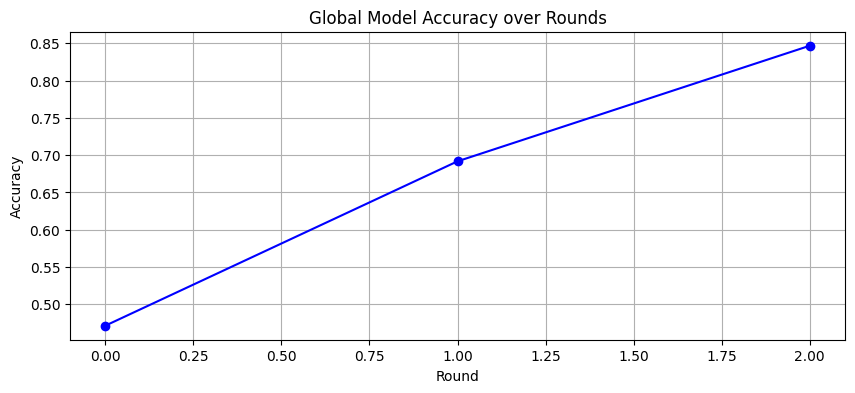

✅ Model loaded from .pth: /content/global_model_final.pth

Evaluating client 0 on validation set...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


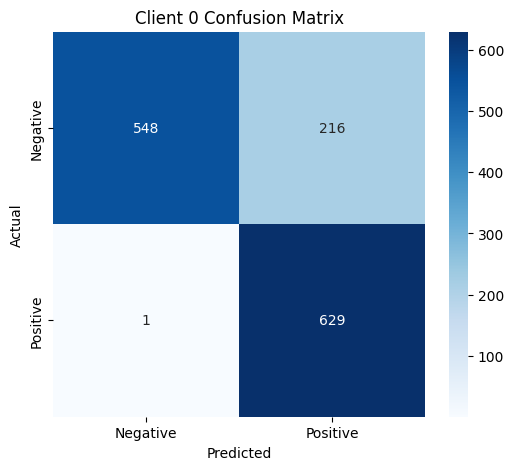

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      0.72      0.83       764
    Positive       0.74      1.00      0.85       630

    accuracy                           0.84      1394
   macro avg       0.87      0.86      0.84      1394
weighted avg       0.88      0.84      0.84      1394


Evaluating client 2 on validation set...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


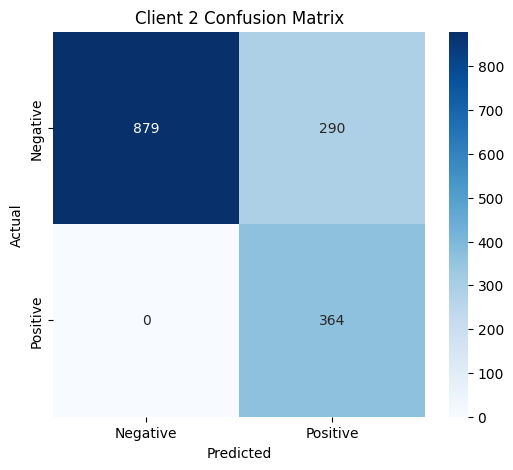

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      0.75      0.86      1169
    Positive       0.56      1.00      0.72       364

    accuracy                           0.81      1533
   macro avg       0.78      0.88      0.79      1533
weighted avg       0.89      0.81      0.82      1533


Evaluating client 3 on validation set...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


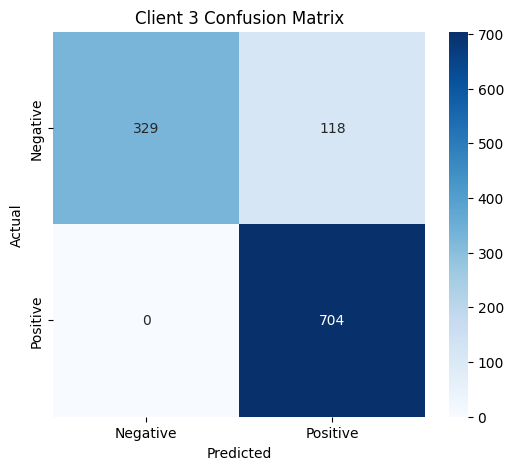

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      0.74      0.85       447
    Positive       0.86      1.00      0.92       704

    accuracy                           0.90      1151
   macro avg       0.93      0.87      0.89      1151
weighted avg       0.91      0.90      0.89      1151


Evaluating TEST set (client_id=0)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader

def visualize_results(history, final_params, client_ids, txt_dir, img_dir, device):
    # Plot global accuracy from history (if available)
    if hasattr(history, "metrics_centralized") and "accuracy" in history.metrics_centralized:
        acc_points = history.metrics_centralized["accuracy"]
        rounds = [x[0] for x in acc_points]
        acc = [x[1] for x in acc_points]

        plt.figure(figsize=(10, 4))
        plt.plot(rounds, acc, marker='o', color='b')
        plt.title("Global Model Accuracy over Rounds")
        plt.xlabel("Round")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.show()

    # Load final global model
    model = load_model_from_pth("/content/global_model_final.pth", device)

    # Evaluate per client
    for client_id in client_ids:
        print(f"\nEvaluating client {client_id} on validation set...")

        # Load validation dataset for this client
        val_txt_path = txt_dir.replace("train.txt", "val.txt")
        val_ds = load_partition(val_txt_path, client_id, img_dir, split="val")
        val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

        y_true = []
        y_pred = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)
                preds = (torch.sigmoid(outputs) > 0.5).float()

                y_true.extend(labels.cpu().numpy().flatten())
                y_pred.extend(preds.cpu().numpy().flatten())

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
        )
        plt.title(f"Client {client_id} Confusion Matrix")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.show()

        # Classification report
        print("\nClassification Report:\n")
        print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

    print("\nEvaluating TEST set (client_id=0)...")
    test_txt_path = txt_dir.replace("train.txt", "test.txt")
    test_ds = load_partition(test_txt_path, client_id=0, img_dir=img_dir, split="test")
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    y_true_test = []
    y_pred_test = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()

            y_true_test.extend(labels.cpu().numpy().flatten())
            y_pred_test.extend(preds.cpu().numpy().flatten())



# Example usage
FINAL_MODEL_PARAMS = strategy.final_parameters
if FINAL_MODEL_PARAMS:
    visualize_results(history, FINAL_MODEL_PARAMS, FEDERATED_CLIENT_IDS, txt_path, img_dir, device)
else:
    print("Simulation did not run or failed to save parameters.")



7. Train using FedProx instead of FedAvg

In [27]:
def train_local(model, train_loader, epochs, lr, device, global_params, mu, pos_weight):
    """
    Local training with FedProx proximal term and automated class weighting.
    """
    model.train()
    model.to(device)

    # Use the specific weight passed from the client (calculated locally)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    total_examples = 0
    running_loss = 0.0

    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_examples = 0
        pbar = tqdm(train_loader, desc=f"Train epoch {epoch+1}/{epochs}", leave=False, ncols=100)

        for X, y in pbar:
            X, y = X.to(device), y.to(device).float()

            optimizer.zero_grad()
            outputs = model(X).view(-1)
            labels = y.view(-1)

            # 1. Standard BCE Loss with pos_weight
            loss = criterion(outputs, labels)

            # 2. FedProx Proximal Term
            # Penalizes local weights for drifting too far from the global model
            prox = torch.tensor(0.0, device=device)
            for w, w_global in zip(model.parameters(), global_params):
                prox += ((w - w_global) ** 2).sum()

            # Total Loss = Classification Loss + Proximal Penalty
            total_loss = loss + (mu / 2) * prox

            total_loss.backward()
            optimizer.step()

            batch_size = X.size(0)
            epoch_loss += total_loss.item() * batch_size
            epoch_examples += batch_size

            pbar.set_postfix({"loss": f"{total_loss.item():.4f}"})

        avg_epoch_loss = epoch_loss / epoch_examples if epoch_examples > 0 else 0.0
        print(f"Epoch {epoch+1}/{epochs} - Avg loss: {avg_epoch_loss:.6f}")

        running_loss += epoch_loss
        total_examples += epoch_examples

    avg_loss = running_loss / total_examples if total_examples > 0 else 0.0
    return avg_loss


def evaluate(model, dataloader, device):
    model.eval()
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()

    threshold = 0.5
    total_loss = 0.0
    total_examples = 0

    # counters for binary confusion matrix
    TP = 0
    TN = 0
    FP = 0
    FN = 0

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device).float()

            outputs = model(X)
            outputs = outputs.view(-1)

            batch_size = X.size(0)
            loss = criterion(outputs, y.view(-1))
            total_loss += loss.item() * batch_size
            total_examples += batch_size

            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).long()
            labels = y.view(-1).long()

            TP += int(((preds == 1) & (labels == 1)).sum().item())
            TN += int(((preds == 0) & (labels == 0)).sum().item())
            FP += int(((preds == 1) & (labels == 0)).sum().item())
            FN += int(((preds == 0) & (labels == 1)).sum().item())

    avg_loss = total_loss / total_examples if total_examples > 0 else 0.0
    eps = 1e-8
    precision = TP / (TP + FP + eps)
    recall = TP / (TP + FN + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    accuracy = (TP + TN) / (TP + TN + FP + FN + eps)

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": TP,
        "tn": TN,
        "fp": FP,
        "fn": FN,
    }
    print(
        f"Eval - Loss: {avg_loss:.6f} | "
        f"Acc: {accuracy:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f} | F1: {f1:.4f} | "
        f"TP: {TP} FP: {FP} FN: {FN} TN: {TN}"
    )

    return avg_loss, metrics


In [30]:
def compute_pos_weight(dataset):
    """
    Computes the pos_weight ratio: (total_negatives / total_positives).
    This helps the model handle class imbalance by weighting the positive class.
    """
    all_labels = []

    # Iterate through the local dataset to collect all labels
    for i in range(len(dataset)):
        _, label = dataset[i]
        all_labels.append(label)

    all_labels = torch.tensor(all_labels)
    num_positives = torch.sum(all_labels).item()
    num_negatives = len(all_labels) - num_positives

    # Formula for pos_weight: Count of Negative / Count of Positive
    # Adding 1e-8 (epsilon) to prevent DivisionByZero if a client has 0 positives
    pos_weight = num_negatives / (num_positives + 1e-8)

    return torch.tensor([pos_weight])

In [31]:
def parameters_to_tensors(parameters, model, device):
    """
    Converts server Parameters to a list of tensors matching model.parameters()
    """
    state_dict = model.state_dict()
    new_params = []
    for key, param in zip(state_dict.keys(), parameters):
        new_params.append(torch.tensor(param, dtype=state_dict[key].dtype, device=device).view(state_dict[key].shape))
    return new_params


class FlowerClient(fl.client.NumPyClient):
    def __init__(self, model, train_ds, val_ds, device, local_epochs=3, lr=1e-5, mu=0.1):
        self.model = model
        self.trainloader = DataLoader(train_ds, batch_size=32, shuffle=True)
        self.testloader  = DataLoader(val_ds, batch_size=32, shuffle=False)
        self.device = device
        self.local_epochs = local_epochs
        self.lr = lr
        self.mu = mu

        # Calculate pos_weight once during initialization
        self.pos_weight = compute_pos_weight(train_ds).to(device)
        print(f"Client Initialized. Local pos_weight: {self.pos_weight.item():.4f}")

    def get_parameters(self, config):
        return [v.cpu().numpy() for v in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        state_dict = {}
        for (k, _), p in zip(self.model.state_dict().items(), parameters):
            state_dict[k] = torch.tensor(p, dtype=torch.float32)
        self.model.load_state_dict(state_dict)

    def fit(self, parameters, config):
        self.set_parameters(parameters)

        # Capture global parameters for the proximal term calculation
        global_params = [p.clone().detach().to(self.device) for p in self.model.parameters()]

        # Pass pos_weight here to match the new train_local signature
        train_loss = train_local(
            self.model,
            self.trainloader,
            epochs=self.local_epochs,
            lr=self.lr,
            device=self.device,
            global_params=global_params,
            mu=self.mu,
            pos_weight=self.pos_weight  # <--- Added this
        )
        return self.get_parameters({}), len(self.trainloader.dataset), {"train_loss": float(train_loss)}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss, metrics = evaluate(self.model, self.testloader, self.device)

        return (
            float(loss),
            len(self.testloader.dataset),
            {
                "accuracy": float(metrics["accuracy"]),
                "precision": float(metrics["precision"]),
                "recall": float(metrics["recall"]),
                "f1": float(metrics["f1"]),
                "tp": float(metrics["tp"]),
                "tn": float(metrics["tn"]),
                "fp": float(metrics["fp"]),
                "fn": float(metrics["fn"]),
            },
        )


In [32]:
class FedProxSave(fl.server.strategy.FedAvg):
    def __init__(self, save_dir: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.final_parameters = None

    def evaluate(self, server_round: int, parameters: fl.common.Parameters, config=None):
        # Save checkpoint
        ndarrays = fl.common.parameters_to_ndarrays(parameters)
        filename = self.save_dir / f"global_round_{server_round}.pkl"
        with open(filename, "wb") as f:
            pickle.dump(ndarrays, f)

        self.final_parameters = parameters
        return super().evaluate(server_round, parameters)


In [36]:
if 'global_model' in locals():
    del global_model

# Clear GPU memory
torch.cuda.empty_cache()

In [37]:
FEDERATED_CLIENT_IDS = [0, 2, 3]
NUM_CLIENTS = len(FEDERATED_CLIENT_IDS)
txt_path = "/content/train.txt"
img_dir = "/content"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- HELPER: Set weights from NumPy arrays ---
def set_weights(model, weights):
    """Load numpy weights into the model."""
    new_state = {}
    for (k, _), w in zip(model.state_dict().items(), weights):
        new_state[k] = torch.tensor(w, dtype=torch.float32)
    model.load_state_dict(new_state)
    return model

# --- CLIENT FACTORY ---
def client_fn(cid: str):
    """Creates a FlowerClient for the specific COVID partition."""
    # Maps cid (0, 1, 2) to [0, 2, 3]
    actual_client_id = FEDERATED_CLIENT_IDS[int(cid)]

    # Load your CXR partitions
    train_ds = load_partition(txt_path, actual_client_id, img_dir, split="train")
    val_ds = load_partition(txt_path.replace("train.txt", "val.txt"), actual_client_id, img_dir, split="val")

    model = get_model()
    model.to(device)

    # Note: local_epochs=3 and mu=0.01 for stable FedProx
    return FlowerClient(
        model=model,
        train_ds=train_ds,
        val_ds=val_ds,
        device=device,
        local_epochs=3,
        lr=1e-5,
        mu=0.01
    ).to_client() # Added to_client() to avoid the DeprecationWarning

# --- STRATEGY CONFIGURATION ---
strategy = FedProxSave(
    save_dir="/content/global_models",
    fraction_fit=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    evaluate_fn=get_server_evaluate_fn(
        txt_path.replace("train.txt", "val.txt"),
        img_dir,
        device,
        client_ids=FEDERATED_CLIENT_IDS
    )
)

# --- START SIMULATION ---
print(f"🚀 Starting FedProx for COVID CXR 4: 15 Rounds, 3 Epochs")

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=15),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 1},
)

# --- SAVE FINAL MODEL ---
last_ckpt = sorted(Path("/content/global_models").glob("global_round_*.pkl"))[-1]
with open(last_ckpt, "rb") as f:
    final_ndarrays = pickle.load(f)

global_model = get_model()
global_model = set_weights(global_model, final_ndarrays)
global_model.to(device)
global_model.eval()

torch.save(global_model.state_dict(), "/content/global_model_final.pth")
print(f"✅ Training complete. Final global model saved to /content/global_model_final.pth")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


🚀 Starting FedProx for COVID CXR 4: 15 Rounds, 3 Epochs


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
2025-12-23 20:54:25,123	INFO worker.py:2007 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'accelerator_type:A100': 1.0, 'node:__internal_head__': 1.0, 'CPU': 12.0, 'object_store_memory': 26728917811.0, 'node:172.28.0.12': 1.0, 'memory': 62367474893.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 1 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(pid=1

(ClientAppActor pid=13913) Client Initialized. Local pos_weight: 0.0711
Eval - Loss: 0.863733 | Acc: 0.5423 | Prec: 0.0000 | Rec: 0.0000 | F1: 0.0000 | TP: 0 FP: 8 FN: 630 TN: 756
Eval - Loss: 0.637120 | Acc: 0.7599 | Prec: 0.1667 | Rec: 0.0027 | F1: 0.0054 | TP: 1 FP: 5 FN: 363 TN: 1164


INFO :      initial parameters (loss, other metrics): 2.5452538607954107, {'accuracy': 0.5806768023526713, 'precision': 0.124999999921875, 'recall': 0.0011778563015242766, 'f1': 0.002333722102065645}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


...

(ClientAppActor pid=13913) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=13913) 
(ClientAppActor pid=13913)             This is a deprecated feature. It will be removed
(ClientAppActor pid=13913)             entirely in future versions of Flower.
(ClientAppActor pid=13913)         


(ClientAppActor pid=13913) Client Initialized. Local pos_weight: 0.2380


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 15 round(s) in 8445.91s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.17507945056118587
INFO :      		round 2: 0.18067990780349907
INFO :      		round 3: 0.20567924291984366
INFO :      		round 4: 0.21595291145108897
INFO :      		round 5: 0.2547054794934898
INFO :      		round 6: 0.2835075503130466
INFO :      		round 7: 0.32669977377963133
INFO :      		round 8: 0.2970626471167254
INFO :      		round 9: 0.3269877427343467
INFO :      		round 10: 0.3447140783048452
INFO :      		round 11: 0.35850409291069835
INFO :      		round 12: 0.3455872703461244
INFO :      		round 13: 0.3634446948868793
INFO :      		round 14: 0.40204516408058105
INFO :      		round 15: 0.3997945517650463
INFO :      	History (loss, centralized):
INFO :      		round 0: 2.5452538607954107
INFO :      		round 1: 0.5213926628121002
INFO :      		round 2: 0.53328974458124

(ClientAppActor pid=13913) Eval - Loss: 0.466023 | Acc: 0.9354 | Prec: 0.7912 | Rec: 0.9890 | F1: 0.8791 | TP: 360 FP: 95 FN: 4 TN: 1074
✅ Training complete. Final global model saved to /content/global_model_final.pth


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


8. Evaluate the Federated model with FedProx

In [38]:
def load_model_from_pth(checkpoint_path, device):
    """
    Loads the ResNet18 model from a standard PyTorch .pth state_dict.
    """
    model = get_model()
    # map_location ensures it loads on CPU if GPU is not available
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pth: {checkpoint_path}")
    return model

def load_model_from_pkl(checkpoint_path, device):
    """
    Loads the ResNet18 model from a Flower .pkl checkpoint (list of NumPy arrays).
    """
    model = get_model()

    # Load the list of numpy arrays
    with open(checkpoint_path, "rb") as f:
        ndarrays = pickle.load(f)

    # Map the numpy arrays to the model's state_dict keys
    params_dict = zip(model.state_dict().keys(), ndarrays)
    state_dict = OrderedDict({k: torch.tensor(v, dtype=torch.float32) for k, v in params_dict})

    model.load_state_dict(state_dict, strict=True)
    model.to(device)
    model.eval()
    print(f"✅ Model loaded from .pkl: {checkpoint_path}")
    return model

In [46]:
!cp /content/global_models/global_round_10.pkl /content/drive/MyDrive/AITDM/AITDM/trained_models/resnet_fedprox/

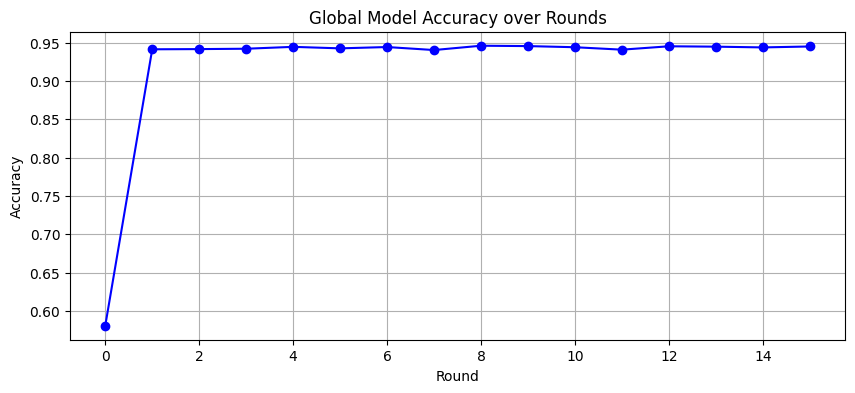

✅ Model loaded from .pth: /content/global_model_final.pth

Evaluating client 0 on validation set...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


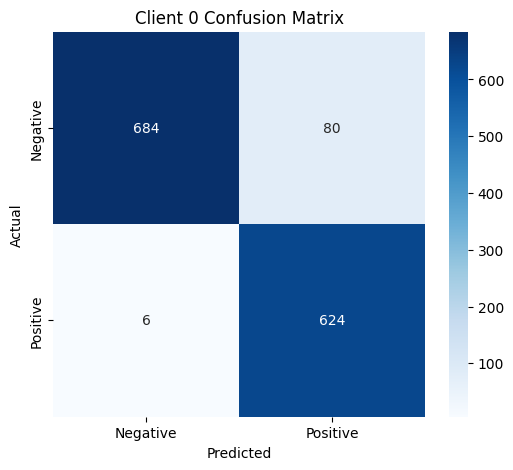

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Classification Report:

              precision    recall  f1-score   support

    Negative       0.99      0.90      0.94       764
    Positive       0.89      0.99      0.94       630

    accuracy                           0.94      1394
   macro avg       0.94      0.94      0.94      1394
weighted avg       0.94      0.94      0.94      1394


Evaluating client 2 on validation set...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


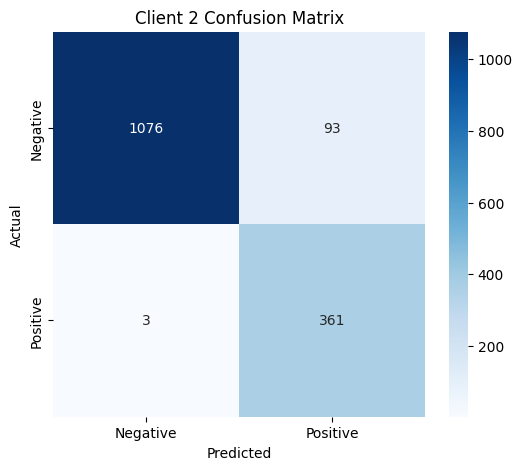

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      0.92      0.96      1169
    Positive       0.80      0.99      0.88       364

    accuracy                           0.94      1533
   macro avg       0.90      0.96      0.92      1533
weighted avg       0.95      0.94      0.94      1533


Evaluating client 3 on validation set...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


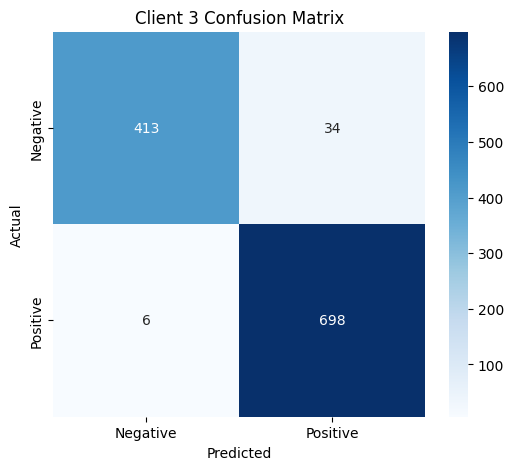


Classification Report:

              precision    recall  f1-score   support

    Negative       0.99      0.92      0.95       447
    Positive       0.95      0.99      0.97       704

    accuracy                           0.97      1151
   macro avg       0.97      0.96      0.96      1151
weighted avg       0.97      0.97      0.97      1151



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader

def visualize_results(history, final_params, client_ids, txt_dir, img_dir, device):
    # Plot global accuracy from history (if available)
    if hasattr(history, "metrics_centralized") and "accuracy" in history.metrics_centralized:
        acc_points = history.metrics_centralized["accuracy"]
        rounds = [x[0] for x in acc_points]
        acc = [x[1] for x in acc_points]

        plt.figure(figsize=(10, 4))
        plt.plot(rounds, acc, marker='o', color='b')
        plt.title("Global Model Accuracy over Rounds")
        plt.xlabel("Round")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.show()

    # Load final global model
    model = load_model_from_pth("/content/global_model_final.pth", device)

    # Evaluate per client
    for client_id in client_ids:
        print(f"\nEvaluating client {client_id} on validation set...")

        # Load validation dataset for this client
        val_txt_path = txt_dir.replace("train.txt", "val.txt")
        val_ds = load_partition(val_txt_path, client_id, img_dir, split="val")
        val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

        y_true = []
        y_pred = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)
                preds = (torch.sigmoid(outputs) > 0.5).float()

                y_true.extend(labels.cpu().numpy().flatten())
                y_pred.extend(preds.cpu().numpy().flatten())

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
        )
        plt.title(f"Client {client_id} Confusion Matrix")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.show()

        # Classification report
        print("\nClassification Report:\n")
        print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))


# Example usage
FINAL_MODEL_PARAMS = strategy.final_parameters
if FINAL_MODEL_PARAMS:
    visualize_results(history, FINAL_MODEL_PARAMS, FEDERATED_CLIENT_IDS, txt_path, img_dir, device)
else:
    print("Simulation did not run or failed to save parameters.")



9. Train only on the first hospital

After training the baseline, we can see that the model is not doing a good job yet. We want to train on the first hospital to see if the problem is from the model, or from the federated part of the code.

In [ ]:
class CovidDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, use_clahe=False, brightness_target=None):
        """
        brightness_target: float or None
            If given, scales the image so that its mean brightness matches this value.
            Useful to align test images with train/val brightness.
        """
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.use_clahe = use_clahe
        self.brightness_target = brightness_target
        if self.use_clahe:
            self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

    def __len__(self):
        return len(self.df)

    def apply_clahe(self, pil_img):
        img = np.array(pil_img.convert("L"))
        img_eq = self.clahe.apply(img)
        img_rgb = cv2.cvtColor(img_eq, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_rgb)

    def apply_brightness(self, pil_img):
        img = np.array(pil_img).astype(np.float32)
        mean_current = img.mean()
        factor = self.brightness_target / (mean_current + 1e-8)
        img = np.clip(img * factor, 0, 255).astype(np.uint8)
        return Image.fromarray(img)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['filename']
        img_path = os.path.join(self.img_dir, img_name)

        if os.path.exists(img_path):
            image = Image.open(img_path).convert('RGB')
        else:
            image = Image.new('RGB', (256, 256))

        if self.use_clahe:
            image = self.apply_clahe(image)

        if self.brightness_target is not None:
            image = self.apply_brightness(image)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor([1.0 if self.df.iloc[idx]['label']=="positive" else 0.0], dtype=torch.float32)
        return image, label

def load_partition(txt_path, client_id, img_dir, split="train", use_clahe=False):
    df = pd.read_csv(
        txt_path, sep=" ", header=None, index_col=False,
        names=["patient_id", "filename", "label", "source", "client_id"]
    )
    client_df = df[df["client_id"] == client_id].copy()

    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
    ])

    dataset = CovidDataset(
        client_df,
        img_dir=os.path.join(img_dir, split),
        transform=transform,
        use_clahe=use_clahe
    )

    return dataset

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        """
        alpha: weight for the positive class (can help with imbalance)
        gamma: focusing parameter (default 2.0)
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        """
        logits: raw outputs from the model (not passed through sigmoid)
        targets: ground truth labels (0 or 1)
        """
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = torch.exp(-bce_loss)
        loss = self.alpha * (1 - p_t)**self.gamma * bce_loss
        return loss.mean()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm import tqdm


def train_single_client(model, client_txt_path, client_id, img_dir, device,
                        lr=1e-4, epochs=10, batch_size=32):
    # Load datasets
    train_ds = load_partition(client_txt_path, client_id, img_dir, split="train")
    val_ds   = load_partition(client_txt_path.replace("train.txt", "val.txt"), client_id, img_dir, split="val")

    # Compute class weights
    labels = [int(y.item()) for _, y in train_ds]
    num_pos = labels.count(1)
    num_neg = labels.count(0)
    pos_weight = torch.tensor(num_neg / (num_pos + 1e-8), dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    trainloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valloader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X, y in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}", ncols=100):
            X, y = X.to(device), y.float().to(device)

            optimizer.zero_grad()
            logits = model(X).view(-1)
            labels = y.view(-1)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * X.size(0)

        avg_loss = total_loss / len(trainloader.dataset)
        print(f"Epoch {epoch+1}/{epochs} - train loss = {avg_loss:.4f}")

        # Validation
        val_loss, metrics = evaluate(model, valloader, device)
        print(
            f"  Val: loss={val_loss:.4f} acc={metrics['accuracy']:.3f} "
            f"prec={metrics['precision']:.3f} rec={metrics['recall']:.3f} "
            f"f1={metrics['f1']:.3f}"
        )

    return model

In [ ]:
def get_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

In [ ]:
train_txt_path = "/content/train.txt"
img_dir        = "/content/"
client_id      = 1

# Train the model on client 0
client_model = get_model()

trained_model = train_single_client(
    model=client_model,
    client_txt_path=train_txt_path,
    client_id=client_id,
    img_dir=img_dir,
    device=device,
    lr=1e-5,
    epochs=5,
    batch_size=32
)


Epoch 1/5:   0%|                                                            | 0/543 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Epoch 1/5: 100%|██████████████████████████████████████████████████| 543/543 [00:40<00:00, 13.57it/s]


Epoch 1/5 - train loss = 0.1244
Eval - Loss: 0.153522 | Acc: 0.9635 | Prec: 0.9782 | Rec: 0.9743 | F1: 0.9762 | TP: 493 FP: 11 FN: 13 TN: 141
  Val: loss=0.1535 acc=0.964 prec=0.978 rec=0.974 f1=0.976


Epoch 2/5: 100%|██████████████████████████████████████████████████| 543/543 [00:39<00:00, 13.64it/s]


Epoch 2/5 - train loss = 0.0720
Eval - Loss: 0.146244 | Acc: 0.9590 | Prec: 0.9780 | Rec: 0.9684 | F1: 0.9732 | TP: 490 FP: 11 FN: 16 TN: 141
  Val: loss=0.1462 acc=0.959 prec=0.978 rec=0.968 f1=0.973


Epoch 3/5: 100%|██████████████████████████████████████████████████| 543/543 [00:39<00:00, 13.61it/s]


Epoch 3/5 - train loss = 0.0496
Eval - Loss: 0.112488 | Acc: 0.9772 | Prec: 0.9786 | Rec: 0.9921 | F1: 0.9853 | TP: 502 FP: 11 FN: 4 TN: 141
  Val: loss=0.1125 acc=0.977 prec=0.979 rec=0.992 f1=0.985


Epoch 4/5: 100%|██████████████████████████████████████████████████| 543/543 [00:39<00:00, 13.62it/s]


Epoch 4/5 - train loss = 0.0327
Eval - Loss: 0.108279 | Acc: 0.9742 | Prec: 0.9785 | Rec: 0.9881 | F1: 0.9833 | TP: 500 FP: 11 FN: 6 TN: 141
  Val: loss=0.1083 acc=0.974 prec=0.978 rec=0.988 f1=0.983


Epoch 5/5: 100%|██████████████████████████████████████████████████| 543/543 [00:40<00:00, 13.57it/s]


Epoch 5/5 - train loss = 0.0172
Eval - Loss: 0.110279 | Acc: 0.9772 | Prec: 0.9786 | Rec: 0.9921 | F1: 0.9853 | TP: 502 FP: 11 FN: 4 TN: 141
  Val: loss=0.1103 acc=0.977 prec=0.979 rec=0.992 f1=0.985


Fine tune on a hold-out set from the test set for domain alignment.

In [ ]:
def fine_tune_on_subset(model, dataset, device,
                        lr=1e-6, epochs=2, batch_size=16):
    """
    Fine-tunes a trained model on any arbitrary dataset (e.g., Client 3 test subset).
    Reuses the same BCEWithLogits + pos_weight logic.
    """

    # ----- Internal 80/20 split -----
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    split = int(0.8 * len(indices))

    train_idx = indices[:split]
    val_idx   = indices[split:]

    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    # ----- Compute pos_weight -----
    labels = []
    for _, y in train_ds:
        labels.append(int(y.item()))

    num_pos = sum(labels)
    num_neg = len(labels) - num_pos
    pos_weight = torch.tensor(num_neg / (num_pos + 1e-8), dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ----- Loaders -----
    trainloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valloader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model.to(device)

    # ----- Fine-tune -----
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X, y in tqdm(trainloader, desc=f"FT Epoch {epoch+1}/{epochs}", ncols=100):
            X, y = X.to(device), y.float().to(device)

            optimizer.zero_grad()
            logits = model(X).view(-1)
            loss = criterion(logits, y.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.size(0)

        print(f"[FT] Epoch {epoch+1}: train loss = {total_loss / len(trainloader.dataset):.4f}")

        val_loss, metrics = evaluate(model, valloader, device)
        print(
            f"  FT Val: loss={val_loss:.4f} acc={metrics['accuracy']:.3f} "
            f"prec={metrics['precision']:.3f} rec={metrics['recall']:.3f} "
            f"f1={metrics['f1']:.3f}"
        )

    return model

In [ ]:
def fine_tune_head(model, dataset, device,
                   lr=1e-5, epochs=2, batch_size=16):

    # Freeze backbone
    for name, param in model.named_parameters():
        if "fc" in name:     # classifier head
            param.requires_grad = True
        else:
            param.requires_grad = False

    head_params = [p for p in model.parameters() if p.requires_grad]

    # Internal split
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    split = int(0.8 * len(indices))

    train_ds = Subset(dataset, indices[:split])
    val_ds   = Subset(dataset, indices[split:])

    # Compute pos_weight
    labels = []
    for _, y in train_ds:
        labels.append(int(y.item()))

    num_pos = sum(labels)
    num_neg = len(labels) - num_pos

    pos_weight = torch.tensor(num_neg / (num_pos + 1e-8)).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.Adam(head_params, lr=lr)

    trainloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valloader   = DataLoader(val_ds, batch_size=batch_size)

    model.to(device)

    # ---- Training ----
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X, y in tqdm(trainloader, desc=f"Head FT {epoch+1}/{epochs}", ncols=120):
            X, y = X.to(device), y.float().to(device)

            optimizer.zero_grad()
            logits = model(X).view(-1)
            loss = criterion(logits, y.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.size(0)

        print(f"[Head FT] Epoch {epoch+1}: loss={total_loss/len(trainloader.dataset):.4f}")

        val_loss, metrics = evaluate(model, valloader, device)
        print(
            f"  Val: loss={val_loss:.4f} acc={metrics['accuracy']:.3f} "
            f"prec={metrics['precision']:.3f} rec={metrics['recall']:.3f} "
            f"f1={metrics['f1']:.3f}"
        )

    return model

def fine_tune_last_block(model, dataset, device,
                         lr=5e-7, epochs=1, batch_size=16):

    # Unfreeze layer4 + fc only
    for name, param in model.named_parameters():
        if "layer4" in name or "fc" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    params = [p for p in model.parameters() if p.requires_grad]

    # Internal split
    indices = list(range(len(dataset)))
    random.shuffle(indices)
    split = int(0.8 * len(indices))

    train_ds = Subset(dataset, indices[:split])
    val_ds   = Subset(dataset, indices[split:])

    # Compute pos_weight
    labels = []
    for _, y in train_ds:
        labels.append(int(y.item()))

    num_pos = sum(labels)
    num_neg = len(labels) - num_pos

    pos_weight = torch.tensor(num_neg / (num_pos + 1e-8)).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.Adam(params, lr=lr)

    trainloader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    valloader   = DataLoader(val_ds, batch_size=batch_size)

    model.to(device)

    # ---- Training ----
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X, y in tqdm(trainloader, desc=f"LastBlock FT {epoch+1}/{epochs}", ncols=120):
            X, y = X.to(device), y.float().to(device)

            optimizer.zero_grad()
            logits = model(X).view(-1)
            loss = criterion(logits, y.view(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.size(0)

        print(f"[LastBlock FT] Epoch {epoch+1}: loss={total_loss/len(trainloader.dataset):.4f}")

        val_loss, metrics = evaluate(model, valloader, device)
        print(
            f"  Val: loss={val_loss:.4f} acc={metrics['accuracy']:.3f} "
            f"prec={metrics['precision']:.3f} rec={metrics['recall']:.3f} "
            f"f1={metrics['f1']:.3f}"
        )

    return model

In [ ]:
test_txt_path = "/content/test.txt"

client3_full = load_partition(
    test_txt_path,
    client_id=3,
    img_dir=img_dir,
    split="test"
)

# Fine-tune for domain adaptation
trained_model_fine_tune = fine_tune_on_subset(
    model=trained_model,
    dataset=client3_full,
    device=device,
    lr=1e-6,
    epochs=2,
    batch_size=16)

FT Epoch 1/2:   0%|                                                          | 0/81 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
FT Epoch 1/2: 100%|█████████████████████████████████████████████████| 81/81 [00:03<00:00, 25.19it/s]


[FT] Epoch 1: train loss = 0.3239
Eval - Loss: 0.810328 | Acc: 0.7121 | Prec: 0.8171 | Rec: 0.8203 | F1: 0.8187 | TP: 210 FP: 47 FN: 46 TN: 20
  FT Val: loss=0.8103 acc=0.712 prec=0.817 rec=0.820 f1=0.819


FT Epoch 2/2: 100%|█████████████████████████████████████████████████| 81/81 [00:03<00:00, 25.89it/s]


[FT] Epoch 2: train loss = 0.2862
Eval - Loss: 0.825113 | Acc: 0.7028 | Prec: 0.8333 | Rec: 0.7812 | F1: 0.8065 | TP: 200 FP: 40 FN: 56 TN: 27
  FT Val: loss=0.8251 acc=0.703 prec=0.833 rec=0.781 f1=0.806


Evaluate on the test set

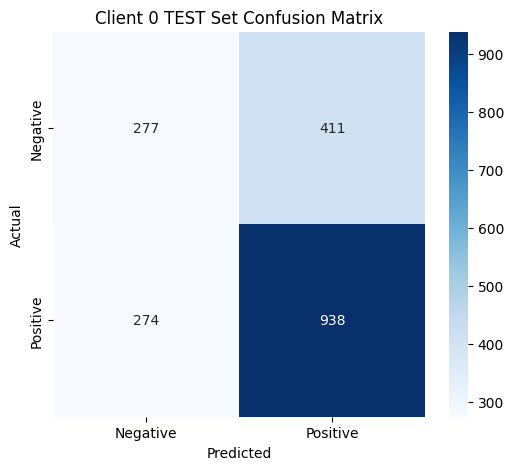


Classification Report:

              precision    recall  f1-score   support

    Negative       0.50      0.40      0.45       688
    Positive       0.70      0.77      0.73      1212

    accuracy                           0.64      1900
   macro avg       0.60      0.59      0.59      1900
weighted avg       0.63      0.64      0.63      1900



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
test_ds = load_partition(
    txt_path=train_txt_path.replace("train.txt", "test.txt"),
    client_id=0,
    img_dir=img_dir,
    split="test"
)

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# --- Put model in eval mode ---
trained_model_fine_tune.to(device)
trained_model_fine_tune.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model_fine_tune(images)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        y_true.extend(labels.cpu().numpy().flatten())
        y_pred.extend(preds.cpu().numpy().flatten())

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title("Client 0 TEST Set Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# --- Classification report ---
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

In [ ]:
train_txt_path = 'train.txt'
test_txt_path = 'test.txt'

The test set is not from the same distribution as the train and validation. Below are the results. The images are generally darker than the other ones.

Missing test images: 0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Processing test: 100%|██████████| 8482/8482 [00:10<00:00, 795.17it/s]


--- Train ---
Brightness mean/std: 113.58 / 12.78
Contrast mean/std:   78.83 / 4.79
Edge var mean/std:   1157.9424 / 1661.9162

--- Val ---
Brightness mean/std: 116.13 / 13.14
Contrast mean/std:   77.79 / 4.54
Edge var mean/std:   801.2465 / 1299.5263

--- Test ---
Brightness mean/std: 105.78 / 12.30
Contrast mean/std:   81.53 / 3.38
Edge var mean/std:   663.7475 / 311.0978



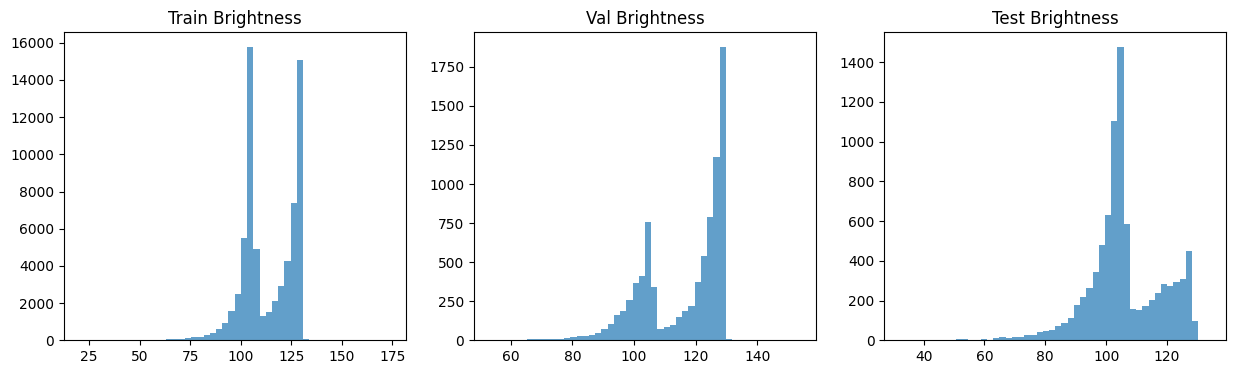

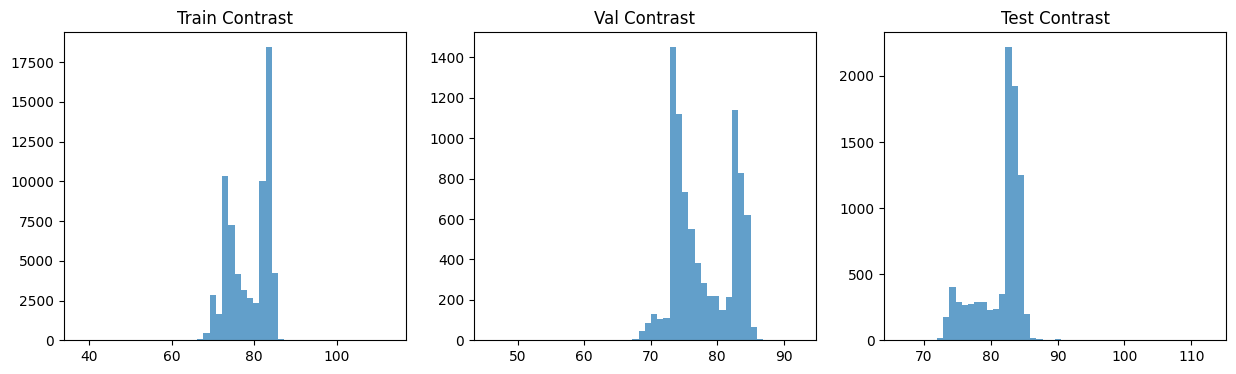

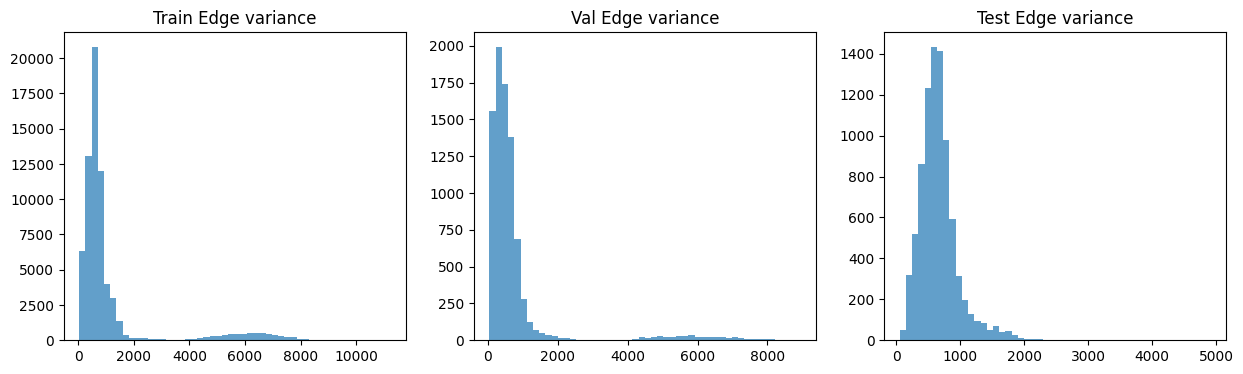

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- Paths ---
img_dir = "/content"  # root folder containing train, val, test
train_txt = "/content/train.txt"
val_txt   = "/content/val.txt"
test_txt  = "/content/test.txt"

def check_missing_images(txt_path, split_folder):
    missing_files = []
    df = pd.read_csv(txt_path, sep=" ", header=None, names=["patient_id", "filename", "label", "source", "client_id"])
    for fname in df['filename']:
        path = os.path.join(img_dir, split_folder, fname)
        if not os.path.exists(path):
            missing_files.append(fname)
    return missing_files

def compute_stats(split_folder):
    folder = os.path.join(img_dir, split_folder)
    img_files = [f for f in os.listdir(folder) if f.lower().endswith(".jpg")]

    brightness = []
    contrast = []
    edge_var = []

    for f in tqdm(img_files, desc=f"Processing {split_folder}"):
        path = os.path.join(folder, f)
        img = cv2.imread(path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))
        contrast.append(np.std(gray))
        edge_var.append(cv2.Laplacian(gray, cv2.CV_64F).var())

    return np.array(brightness), np.array(contrast), np.array(edge_var)

# --- Check missing test images ---
missing_test_files = check_missing_images(test_txt, "test")
print(f"Missing test images: {len(missing_test_files)}")
if len(missing_test_files) > 0:
    print(missing_test_files[:20], " ...")

# --- Compute statistics ---
train_b, train_c, train_e = compute_stats("train")
val_b, val_c, val_e = compute_stats("val")
test_b, test_c, test_e = compute_stats("test")

# --- Print summary ---
for name, b, c, e in zip(["Train", "Val", "Test"],
                         [train_b, val_b, test_b],
                         [train_c, val_c, test_c],
                         [train_e, val_e, test_e]):
    print(f"--- {name} ---")
    print(f"Brightness mean/std: {b.mean():.2f} / {b.std():.2f}")
    print(f"Contrast mean/std:   {c.mean():.2f} / {c.std():.2f}")
    print(f"Edge var mean/std:   {e.mean():.4f} / {e.std():.4f}\n")

# --- Plot histograms ---
plt.figure(figsize=(15,4))
for i, (arr, label) in enumerate(zip([train_b, val_b, test_b], ["Train", "Val", "Test"])):
    plt.subplot(1,3,i+1)
    plt.hist(arr, bins=50, alpha=0.7)
    plt.title(f"{label} Brightness")
plt.show()

plt.figure(figsize=(15,4))
for i, (arr, label) in enumerate(zip([train_c, val_c, test_c], ["Train", "Val", "Test"])):
    plt.subplot(1,3,i+1)
    plt.hist(arr, bins=50, alpha=0.7)
    plt.title(f"{label} Contrast")
plt.show()

plt.figure(figsize=(15,4))
for i, (arr, label) in enumerate(zip([train_e, val_e, test_e], ["Train", "Val", "Test"])):
    plt.subplot(1,3,i+1)
    plt.hist(arr, bins=50, alpha=0.7)
    plt.title(f"{label} Edge variance")
plt.show()
